# Neural Population Simulation

In [1]:
import numpy as np
from matplotlib.pyplot import subplots
from pathlib import Path
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))
from dynamics import *
from simulations import *

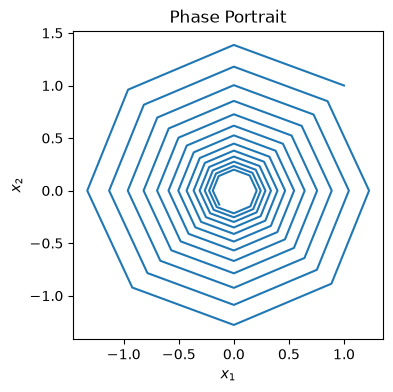

In [2]:
theta = np.pi/4
r = 0.98
x0 = np.array([1, 1])
T = 100
A = damped_rotation_matrix(theta, r)
X = simulate_linear_system(A, x0, T)
x1 = X[:, 0]
x2 = X[:, 1]
fig, ax = subplots(nrows=1, ncols=1, figsize=(4,4))
ax.set_title("Phase Portrait")
ax.plot(x1, x2)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$");

Recall the damped spiral trajectory shown above. In this simulation, we choose A to be a damped rotation matrix that rotates the latent state by 45° counterclockwise at each time step whil shriking its magnitude by a factor of r. As a result, the latent trajectory spirals inward towards the origin. 

## Simulation

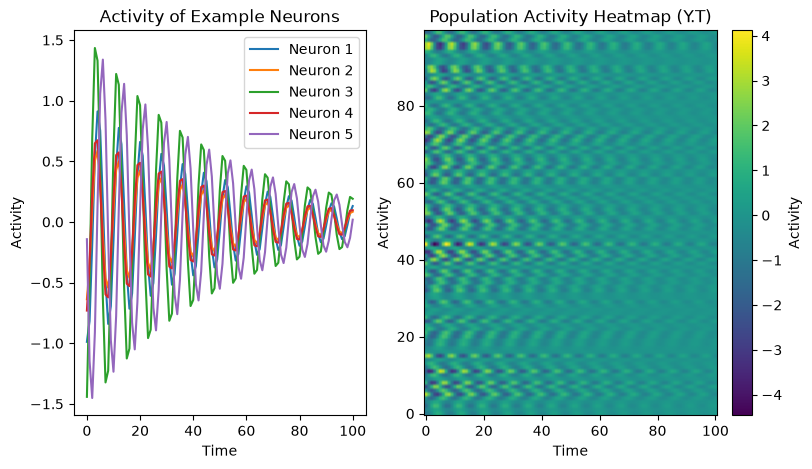

In [3]:
n_neurons = 100
latent_dim = x0.shape[0]
C = generate_observation_matrix(n_neurons, latent_dim, scale=1.0)
Y = X @ C.T
t = np.arange(Y.shape[0])

fig, ax = subplots(nrows=1, ncols=2, figsize=(10,5))
for i in range(5):
    ax[0].plot(t, Y[:, i], label= f"Neuron {i+1}")
ax[0].set_title("Activity of Example Neurons")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Activity")
ax[0].legend();

im = ax[1].imshow(Y.T, aspect='auto', cmap='viridis', origin='lower')
ax[1].set_title("Population Activity Heatmap (Y.T)")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Activity")
cbar = fig.colorbar(im, ax=ax, pad = 0.02)
cbar.set_label("Activity")

The plot on the left shows the activity of five example neurons over time. Although each neuron has a different initial activity and amplitude, they all exhibit the same underlying damped osciallayory behavior because they are driven by the same latent dynamics. The heatmap on the right displays the activity of the entire neural population. This reveals the coordinated activity across the neural population, suggesting that many neurons are driven by the same underlying latent dynamics.

## Adding Noise

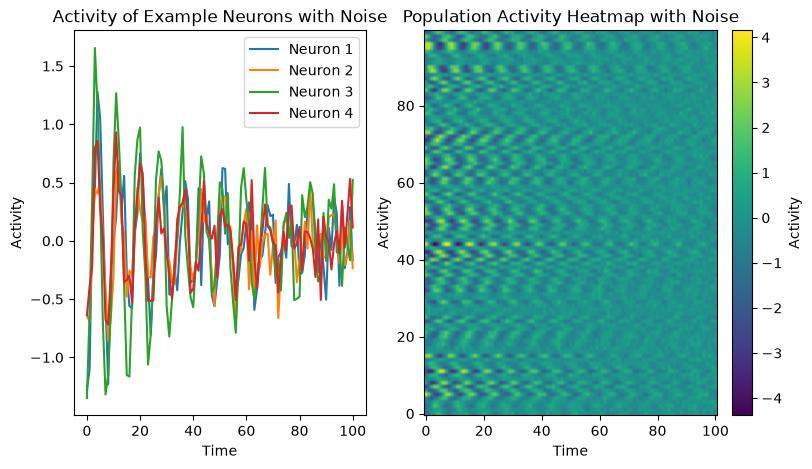

In [4]:
noise_std = 0.2
Y_noise = add_observation_noise(Y, noise_std)
fig, ax = subplots(nrows=1, ncols=2, figsize=(10,5))
for i in range(4):
    ax[0].plot(t, Y_noise[:, i], label= f"Neuron {i+1}")
ax[0].set_title("Activity of Example Neurons with Noise")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Activity")
ax[0].legend();

im = ax[1].imshow(Y_noise.T, aspect='auto', cmap='viridis', origin='lower')
ax[1].set_title("Population Activity Heatmap with Noise")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Activity")
cbar = fig.colorbar(im, ax=ax, pad = 0.02)
cbar.set_label("Activity")

After adding Gaussian observation noise, the activity of the example neurons don't display perfectly smooth damped oscillations. Likewise, the population activity heatmap appears grainier, reflecting noise while still preserving the underlying low-dimensional structure.